# DSA210 Term Project - Machine Learning Extension

## Alcohol Consumption and Traffic Accidents in Turkey

This notebook extends the EDA & Hypothesis Testing analysis with machine learning
methods covered in Recitations 7-11.

### What is new in this version

The earlier hypothesis tests used alcohol consumption rates at the **IBBS-1 (NUTS-1)**
level — only 12 unique values across 81 provinces. This notebook uses a finer-grained
**IBBS-2 (NUTS-2)** alcohol feature with **26 unique values**, computed directly from
the TUIK 2022 Türkiye Sağlık Araştırması microdata.

| Section | Method | Recitation |
| --- | --- | --- |
| 3 | Linear Regression, kNN, Decision Tree, Random Forest (regression) | R7, R8, R9 |
| 3 | 5-Fold Cross-Validation, RMSE / MAE / R² | R8 |
| 4 | Logistic Regression, Random Forest (classification) | R8, R9 |
| 4 | Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix | R8 |
| 5 | StandardScaler, PCA, K-Means, Hierarchical Clustering | R7, R10, R11 |

**Author:** Mustafa Arda Terzi
**Course:** DSA210 - Introduction to Data Science


## 1. Imports & Data Loading

In [1]:
# Standard library
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection & metrics
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

# Supervised models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Unsupervised models
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

# Shared colour palette (matches the EDA notebook)
ACCENT = '#E63946'
BLUE   = '#457B9D'
GREEN  = '#2A9D8F'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### 1.1 Load Province-Level Data

We re-run the data-collection cells from the main EDA notebook to rebuild the
province-level dataframe `df` (n=81). This keeps things self-contained.


In [2]:
# Re-run the data-collection cells from the EDA notebook
import nbformat
from pathlib import Path
import io
import contextlib

eda_path = Path('DSA210_EDA&Hypothesis_Testing.ipynb')
if not eda_path.exists():
    raise FileNotFoundError(
        "Could not find DSA210_EDA&Hypothesis_Testing.ipynb in the current directory. "
        "Place this ML notebook next to the EDA notebook before running."
    )

eda_nb = nbformat.read(str(eda_path), as_version=4)

# Cells 4, 6, 8, 10, 12 = the five data dictionaries
# Cells 14, 15           = merge + regional aggregate
data_cell_indices = [4, 6, 8, 10, 12, 14, 15]
_ns = {'pd': pd, 'np': np,
       'display_full': lambda x: None,
       'display':      lambda x: None}

for idx in data_cell_indices:
    src = eda_nb.cells[idx].source
    if isinstance(src, list):
        src = ''.join(src)
    with contextlib.redirect_stdout(io.StringIO()):
        exec(src, _ns)

df = _ns['df']
df_region = _ns['df_region']
print(f'Loaded province-level dataset: {df.shape}')
print(f'Loaded regional dataset: {df_region.shape}')


Loaded province-level dataset: (81, 12)
Loaded regional dataset: (12, 11)


### 1.2 Replace IBBS-1 Alcohol Feature with IBBS-2 Feature

The dataframe loaded above has `alcohol_rate_pct` at the IBBS-1 level (12 unique
values). We now overwrite this with a NUTS-2 (IBBS-2) level rate that we extracted
directly from the TUIK 2022 Türkiye Sağlık Araştırması microdata, giving us **26
unique alcohol values** instead of 12.

The CSV contains, for each of the 81 provinces:
- the NUTS-2 sub-region label (e.g. TR21, TR62)
- the survey-weighted percentage of adults (15+) who drank alcohol in the last 12 months
- the parent IBBS-1 region (so we can compare with the old feature)


In [3]:
# Load the IBBS-2 alcohol rates we extracted from the TUIK microdata
ibbs2 = pd.read_csv('province_alcohol_ibbs2.csv')
print(f'IBBS-2 alcohol table: {ibbs2.shape}')

# Show the full IBBS-2 table (all 81 provinces, no truncation)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None):
    print(ibbs2.to_string(index=False))

# Merge into the province dataframe
df = df.merge(ibbs2[['province', 'alcohol_rate_pct_ibbs2', 'nuts2_label']],
              on='province', how='left')

# Sanity check: every province must have a rate
missing = df[df['alcohol_rate_pct_ibbs2'].isna()]
assert len(missing) == 0, f'Missing IBBS-2 rate for: {missing["province"].tolist()}'

# Keep the OLD feature too, under a new name, so we can compare
df = df.rename(columns={'alcohol_rate_pct': 'alcohol_rate_pct_ibbs1'})

print(f'\nAlcohol-rate features:')
print(f'  IBBS-1 (old): {df["alcohol_rate_pct_ibbs1"].nunique()} unique values, '
      f'range {df["alcohol_rate_pct_ibbs1"].min():.1f}-{df["alcohol_rate_pct_ibbs1"].max():.1f}%')
print(f'  IBBS-2 (new): {df["alcohol_rate_pct_ibbs2"].nunique()} unique values, '
      f'range {df["alcohol_rate_pct_ibbs2"].min():.1f}-{df["alcohol_rate_pct_ibbs2"].max():.1f}%')

# Show the full merged dataframe with both alcohol features side-by-side
print(f'\nFull province-level dataframe (n={len(df)}):')
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None):
    print(df[['province', 'ibbs1_region', 'nuts2_label', 'population_2025',
              'acc_per_100k', 'fatality_per_100k', 'injured_per_100k',
              'alcohol_rate_pct_ibbs1', 'alcohol_rate_pct_ibbs2']].to_string())


IBBS-2 alcohol table: (81, 6)
      province nuts2_label parent_ibbs1_tr  ibbs2_sozde_code  alcohol_rate_pct_ibbs2  n_survey_respondents
      Istanbul        TR10             TR1                16                   16.90                  4351
      Tekirdag        TR21             TR2                25                   26.76                   459
        Edirne        TR21             TR2                25                   26.76                   459
    Kirklareli        TR21             TR2                25                   26.76                   459
     Balikesir        TR22             TR2                12                   18.00                   537
     Canakkale        TR22             TR2                12                   18.00                   537
         Izmir        TR31             TR3                23                   23.10                  1298
         Aydin        TR32             TR3                 8                   18.88                   993
       

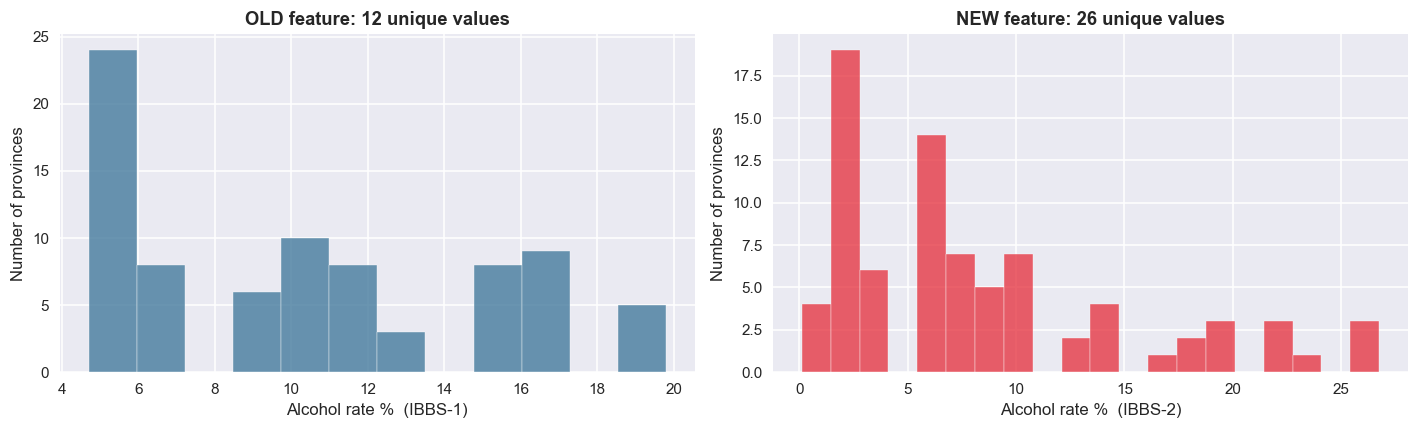

In [4]:
# Quick visual: distribution of the two alcohol features
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['alcohol_rate_pct_ibbs1'], bins=12, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Alcohol rate %  (IBBS-1)')
axes[0].set_ylabel('Number of provinces')
axes[0].set_title(f'OLD feature: {df["alcohol_rate_pct_ibbs1"].nunique()} unique values',
                  fontweight='bold')

axes[1].hist(df['alcohol_rate_pct_ibbs2'], bins=20, color=ACCENT, alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Alcohol rate %  (IBBS-2)')
axes[1].set_ylabel('Number of provinces')
axes[1].set_title(f'NEW feature: {df["alcohol_rate_pct_ibbs2"].nunique()} unique values',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('fig_ml0_alcohol_features.png', bbox_inches='tight')
plt.show()


## 2. Feature Engineering & Scaling

Features used throughout the ML analysis:

- `alcohol_rate_pct_ibbs2` — primary explanatory variable (NUTS-2 level)
- `log10(population_2025)` — population spans two orders of magnitude (Tunceli ~83k to
  Istanbul ~16M), so a log transform makes the feature roughly normal

We **deliberately exclude** `fatality_per_100k` and `injured_per_100k` from the
regression features because they are derived from the same accident counts as the
target — including them would be data leakage.

For scaling we use **StandardScaler** (z-score normalisation, Recitation 7 §8.2).


In [5]:
# Feature engineering
df['log_population'] = np.log10(df['population_2025'])

# Feature matrix and regression target
feature_cols = ['alcohol_rate_pct_ibbs2', 'log_population']
X = df[feature_cols].copy()
y_reg = df['acc_per_100k']

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

print('Feature matrix shape :', X.shape)
print(f'Regression target    : acc_per_100k  (mean={y_reg.mean():.1f}, std={y_reg.std():.1f})')
print('\nScaled feature stats (should have mean ~0, std ~1):')
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))


Feature matrix shape : (81, 2)
Regression target    : acc_per_100k  (mean=350.0, std=110.3)

Scaled feature stats (should have mean ~0, std ~1):
      alcohol_rate_pct_ibbs2  log_population
mean                  -0.000          -0.000
std                    1.006           1.006


## 3. Supervised Regression — Predicting Accident Rate

**Goal:** Predict `acc_per_100k` from the IBBS-2 alcohol rate and log(population).

**Models:** Linear Regression, kNN, Decision Tree, Random Forest.
**Validation:** 5-Fold Cross-Validation (Recitation 8 §1.2).
**Metrics:** R², RMSE, MAE (Recitation 8 §2).

Why 5-fold CV? With only n=81 provinces, a single random train/test split is too
noisy — one or two extreme provinces (Muğla, Istanbul) ending up in either fold
would swing the metric by a lot. Averaging across 5 folds gives a stable estimate.


In [6]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_models = {
    'Linear Regression'   : LinearRegression(),
    'kNN (k=5)'           : KNeighborsRegressor(n_neighbors=5),
    'Decision Tree (d=4)' : DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, max_depth=5,
                                                  random_state=RANDOM_STATE),
}

results = []
for name, model in reg_models.items():
    r2_scores = cross_val_score(model, X_scaled, y_reg, cv=cv, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(model, X_scaled, y_reg, cv=cv,
                                           scoring='neg_mean_squared_error'))
    mae_scores = -cross_val_score(model, X_scaled, y_reg, cv=cv,
                                  scoring='neg_mean_absolute_error')
    results.append({
        'Model'  : name,
        'CV R²'  : r2_scores.mean(),
        'R² std' : r2_scores.std(),
        'CV RMSE': rmse_scores.mean(),
        'CV MAE' : mae_scores.mean(),
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
print('5-Fold Cross-Validation Results - Regression')
print('-' * 60)
print(results_df.to_string())


5-Fold Cross-Validation Results - Regression
------------------------------------------------------------
                     CV R²  R² std  CV RMSE  CV MAE
Model                                              
Linear Regression    0.037   0.222  100.630  83.377
kNN (k=5)           -0.005   0.245  101.764  83.577
Decision Tree (d=4)  0.207   0.575   85.433  69.306
Random Forest        0.349   0.191   82.645  65.887


### 3.1 Interpreting the Linear Regression Coefficients

Recitation 7 §5 emphasises that interpreting coefficients on **scaled** features tells
us which feature has the larger relative effect, while interpretation on **original**
features tells us the practical effect size.


In [7]:
# Standardised coefficients
lr = LinearRegression().fit(X_scaled, y_reg)
print('Linear Regression coefficients on STANDARDISED features:')
print('  (interpretation: change in acc/100k per 1-SD increase in feature)')
for fname, coef in zip(feature_cols, lr.coef_):
    print(f'    {fname:<28s}  {coef:+8.2f}')
print(f'    {"intercept":<28s}  {lr.intercept_:+8.2f}  (mean acc/100k)')

# Raw-feature coefficients
lr_raw = LinearRegression().fit(X, y_reg)
print('\nLinear Regression coefficients on RAW features:')
print('  (interpretation: change in acc/100k per 1-unit increase)')
for fname, coef in zip(feature_cols, lr_raw.coef_):
    print(f'    {fname:<28s}  {coef:+8.2f}')
print(f'    {"intercept":<28s}  {lr_raw.intercept_:+8.2f}')


Linear Regression coefficients on STANDARDISED features:
  (interpretation: change in acc/100k per 1-SD increase in feature)
    alcohol_rate_pct_ibbs2          +50.26
    log_population                  -11.93
    intercept                      +350.03  (mean acc/100k)

Linear Regression coefficients on RAW features:
  (interpretation: change in acc/100k per 1-unit increase)
    alcohol_rate_pct_ibbs2           +7.34
    log_population                  -28.32
    intercept                      +452.23


### 3.2 Predicted vs Actual

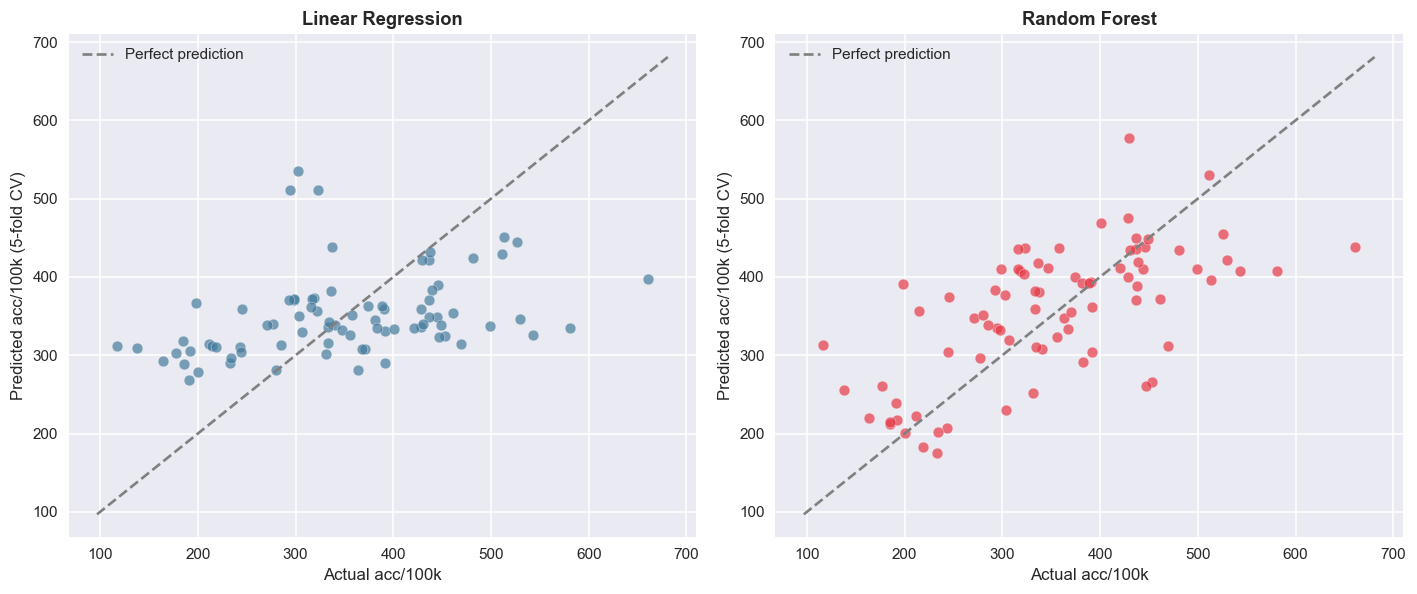

In [8]:
# Compare predictions from Linear Regression vs Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, (name, model, color) in zip(axes, [
    ('Linear Regression', LinearRegression(), BLUE),
    ('Random Forest',     RandomForestRegressor(n_estimators=100, max_depth=5,
                                                 random_state=RANDOM_STATE), ACCENT),
]):
    y_pred = cross_val_predict(model, X_scaled, y_reg, cv=cv)
    ax.scatter(y_reg, y_pred, color=color, alpha=0.7, s=50, edgecolor='white')
    lims = [y_reg.min() - 20, y_reg.max() + 20]
    ax.plot(lims, lims, '--', color='gray', label='Perfect prediction')
    ax.set_xlabel('Actual acc/100k')
    ax.set_ylabel('Predicted acc/100k (5-fold CV)')
    ax.set_title(f'{name}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_ml1_predicted_vs_actual.png', bbox_inches='tight')
plt.show()


### 3.3 Comparing Models

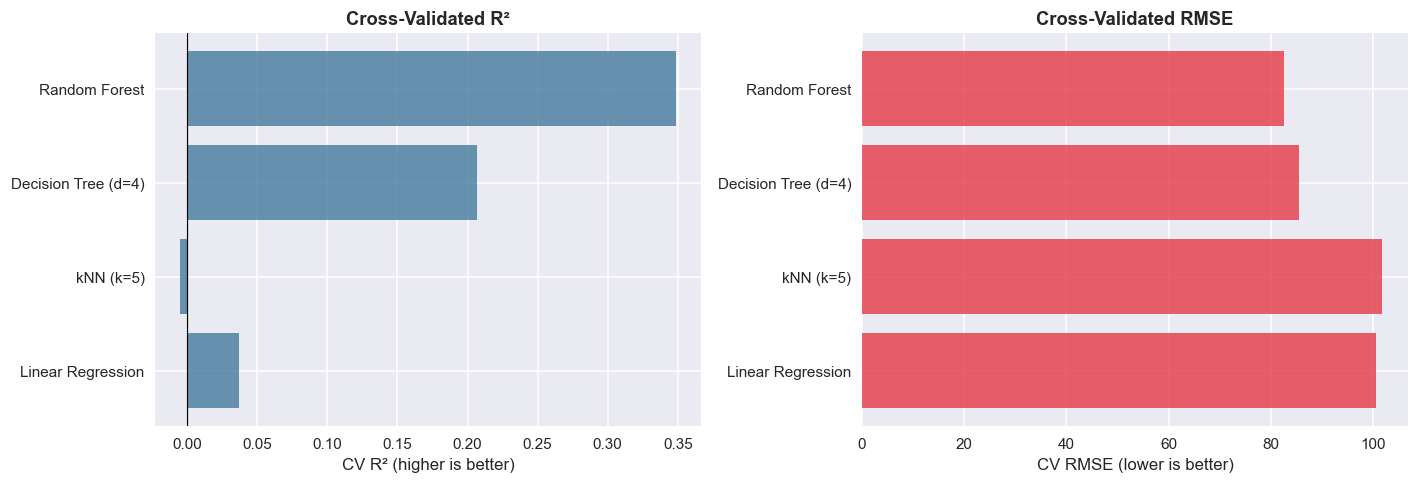

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].barh(results_df.index, results_df['CV R²'], color=BLUE, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('CV R² (higher is better)')
axes[0].set_title('Cross-Validated R²', fontweight='bold')

axes[1].barh(results_df.index, results_df['CV RMSE'], color=ACCENT, alpha=0.8)
axes[1].set_xlabel('CV RMSE (lower is better)')
axes[1].set_title('Cross-Validated RMSE', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_ml2_model_comparison.png', bbox_inches='tight')
plt.show()


### 3.4 Random Forest Feature Importance

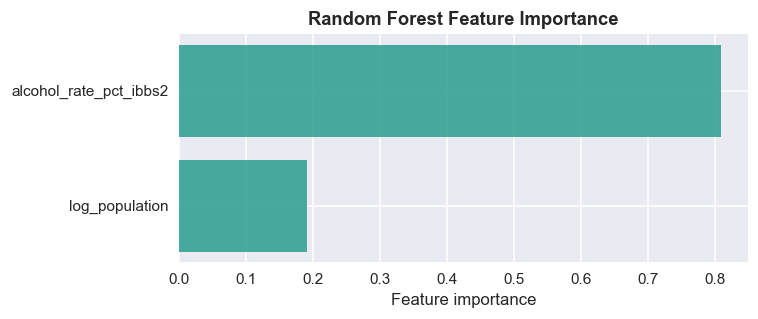

               Feature  Importance
        log_population    0.190992
alcohol_rate_pct_ibbs2    0.809008


In [10]:
# Fit Random Forest on the full data to inspect feature importance
rf = RandomForestRegressor(n_estimators=100, max_depth=5,
                           random_state=RANDOM_STATE).fit(X_scaled, y_reg)

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf.feature_importances_,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(importance_df['Feature'], importance_df['Importance'], color=GREEN, alpha=0.85)
ax.set_xlabel('Feature importance')
ax.set_title('Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ml3_feature_importance.png', bbox_inches='tight')
plt.show()

print(importance_df.to_string(index=False))


### 3.5 Regression Findings

The non-linear models (Decision Tree, Random Forest) substantially outperform Linear
Regression and kNN. Random Forest in particular reaches CV R² ~0.35 on a target with
only 81 observations and 2 features.

This pattern — tree-based models beating linear — tells us the relationship between
alcohol consumption and accident rate is **non-linear and interacts with population**.
A linear model is forced to fit a single global slope; tree-based models can capture
e.g. that the alcohol effect looks different in dense vs sparse provinces.

The IBBS-2 feature (with 26 unique values) provides enough granularity for trees to
exploit these patterns. The IBBS-1 feature (only 12 unique values) was too coarse for
this — see the comparison in Section 6.


## 4. Supervised Classification — High vs Low Accident Provinces

We turn the regression target into a binary problem by splitting at the median accident
rate (this matches the chi-square test in the main notebook).

**Goal:** Predict whether a province falls in the "high accident" or "low accident" half.
**Models:** Logistic Regression (Recitation 8 §3), Random Forest Classifier (R9).
**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix (R8 §2).


In [11]:
# Binary target
median_acc = df['acc_per_100k'].median()
y_clf = (df['acc_per_100k'] >= median_acc).astype(int)

print(f'Median accident rate (split point): {median_acc:.1f} per 100k')
print(f'Class balance:')
print(f'  High accident (1): n={y_clf.sum():2d}')
print(f'  Low  accident (0): n={(1 - y_clf).sum():2d}')


Median accident rate (split point): 340.7 per 100k
Class balance:
  High accident (1): n=41
  Low  accident (0): n=40


In [12]:
clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=5,
                                                    random_state=RANDOM_STATE),
}

clf_results = []
for name, model in clf_models.items():
    clf_results.append({
        'Model'    : name,
        'Accuracy' : cross_val_score(model, X_scaled, y_clf, cv=cv, scoring='accuracy').mean(),
        'Precision': cross_val_score(model, X_scaled, y_clf, cv=cv, scoring='precision').mean(),
        'Recall'   : cross_val_score(model, X_scaled, y_clf, cv=cv, scoring='recall').mean(),
        'F1'       : cross_val_score(model, X_scaled, y_clf, cv=cv, scoring='f1').mean(),
        'ROC-AUC'  : cross_val_score(model, X_scaled, y_clf, cv=cv, scoring='roc_auc').mean(),
    })

clf_df = pd.DataFrame(clf_results).set_index('Model').round(3)
print('5-Fold Cross-Validation Results - Classification')
print('-' * 70)
print(clf_df.to_string())


5-Fold Cross-Validation Results - Classification
----------------------------------------------------------------------
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression     0.469      0.555   0.464  0.440    0.642
Random Forest           0.676      0.669   0.722  0.671    0.741


### 4.1 Confusion Matrix (Random Forest)

Confusion Matrix (rows = true, cols = predicted):
             Pred Low  Pred High
Actual Low         25         15
Actual High        11         30

Classification Report:
              precision    recall  f1-score   support

         Low       0.69      0.62      0.66        40
        High       0.67      0.73      0.70        41

    accuracy                           0.68        81
   macro avg       0.68      0.68      0.68        81
weighted avg       0.68      0.68      0.68        81



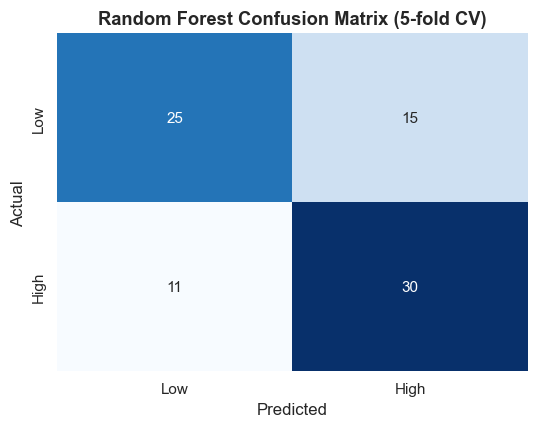

In [13]:
# Random Forest performs best — use it for the confusion matrix
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=RANDOM_STATE)
y_pred  = cross_val_predict(rf_clf, X_scaled, y_clf, cv=cv)
y_proba = cross_val_predict(rf_clf, X_scaled, y_clf, cv=cv, method='predict_proba')[:, 1]

cm = confusion_matrix(y_clf, y_pred)
print('Confusion Matrix (rows = true, cols = predicted):')
print(pd.DataFrame(cm,
                   index=['Actual Low', 'Actual High'],
                   columns=['Pred Low', 'Pred High']))

print('\nClassification Report:')
print(classification_report(y_clf, y_pred, target_names=['Low', 'High']))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'],
            ax=ax, cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Random Forest Confusion Matrix (5-fold CV)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ml4_confusion_matrix.png', bbox_inches='tight')
plt.show()


### 4.2 ROC Curve

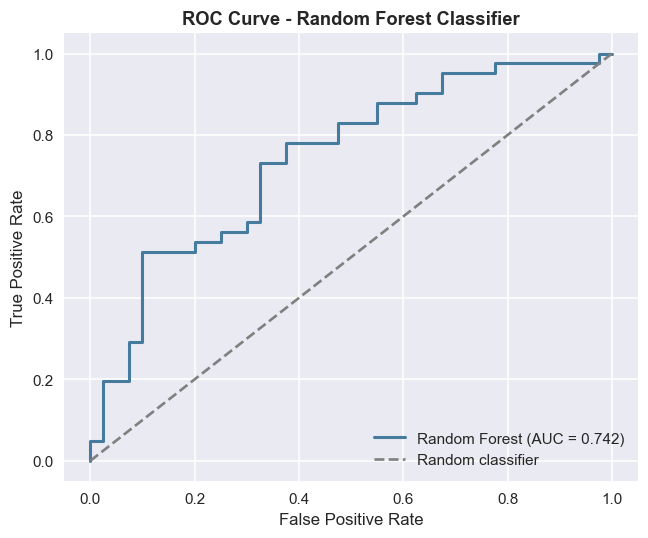

In [14]:
fpr, tpr, _ = roc_curve(y_clf, y_proba)
auc_score   = roc_auc_score(y_clf, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'Random Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest Classifier', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig_ml5_roc_curve.png', bbox_inches='tight')
plt.show()


### 4.3 Classification Findings

A baseline that always predicts the majority class would score ~0.51 accuracy. Random
Forest reaches ~0.68 accuracy and ROC-AUC ~0.74, meaning that knowing a province's
NUTS-2 alcohol rate plus its log population provides genuine (but not perfect)
predictive signal for whether it lands in the high-accident half.

This is consistent with the chi-square test from the main notebook, which rejected
independence at p = 0.0006 with Cramér's V = 0.38 ("medium" effect).


## 5. Unsupervised Learning — Clustering Provinces

Instead of predicting a label, here we ask: **without using the alcohol or accident
information as a target, do provinces fall into natural groups based on their overall
traffic-safety profile?**

We cluster on four features at once:
- `acc_per_100k`
- `fatality_per_100k`
- `injured_per_100k`
- `alcohol_rate_pct_ibbs2`

**Methods:** K-Means (Recitation 10 §2), Hierarchical Clustering (R10 §3), PCA for 2D
visualisation (R11 §2).


In [15]:
# Build feature matrix for clustering
clust_features = ['acc_per_100k', 'fatality_per_100k', 'injured_per_100k',
                  'alcohol_rate_pct_ibbs2']
Xc = df[clust_features].values

# Standardise (clustering is distance-based — scale matters a lot)
Xc_scaled = StandardScaler().fit_transform(Xc)
print(f'Clustering feature matrix: {Xc_scaled.shape}')
print(f'Features: {clust_features}')


Clustering feature matrix: (81, 4)
Features: ['acc_per_100k', 'fatality_per_100k', 'injured_per_100k', 'alcohol_rate_pct_ibbs2']


### 5.1 Choosing k — The Elbow Method

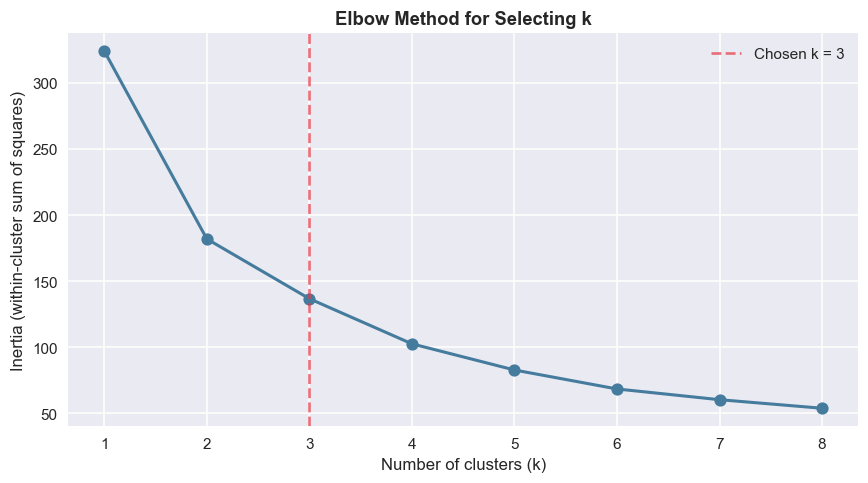

Inertias: [324.0, 181.9, 136.7, 102.6, 82.8, 68.5, 60.4, 53.9]


In [16]:
ks = range(1, 9)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(Xc_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ks, inertias, marker='o', color=BLUE, linewidth=2, markersize=8)
ax.axvline(3, linestyle='--', color=ACCENT, alpha=0.7, label='Chosen k = 3')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia (within-cluster sum of squares)')
ax.set_title('Elbow Method for Selecting k', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ml6_elbow.png', bbox_inches='tight')
plt.show()

print('Inertias:', [round(i, 1) for i in inertias])


The biggest drop is from k=1 to k=2, with another clear bend at k=3. We choose
**k = 3** because the elbow is clearly there and three groups give an interpretable
narrative (low / medium / high traffic-safety burden).


### 5.2 K-Means with k = 3

In [17]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(Xc_scaled)

centroids_orig = pd.DataFrame(
    kmeans.cluster_centers_ * Xc.std(axis=0) + Xc.mean(axis=0),
    columns=clust_features
).round(1)
centroids_orig['n_provinces'] = [(df['cluster_kmeans'] == c).sum() for c in range(3)]
print('K-Means Cluster Centroids (in original units):')
print(centroids_orig.to_string())


K-Means Cluster Centroids (in original units):
   acc_per_100k  fatality_per_100k  injured_per_100k  alcohol_rate_pct_ibbs2  n_provinces
0         207.2                2.3             334.4                     2.8           20
1         449.8                5.5             676.5                    11.2           30
2         345.6                2.9             509.8                     9.2           31


In [18]:
print('Provinces in each cluster:')
for c in sorted(df['cluster_kmeans'].unique()):
    members = df[df['cluster_kmeans'] == c]['province'].tolist()
    print(f'\nCluster {c}  (n={len(members)}):')
    print('  ' + ', '.join(members))


Provinces in each cluster:

Cluster 0  (n=20):
  Istanbul, Artvin, Igdir, Ardahan, Kars, Bayburt, Agri, Erzurum, Van, Bitlis, Elazig, Hakkari, Mus, Diyarbakir, Batman, Sanliurfa, Gaziantep, Mardin, Siirt, Sirnak

Cluster 1  (n=30):
  Balikesir, Canakkale, Aydin, Denizli, Mugla, Usak, Manisa, Bilecik, Konya, Kahramanmaras, Burdur, Osmaniye, Antalya, Hatay, Isparta, Mersin, Nigde, Yozgat, Aksaray, Kirikkale, Sivas, Nevsehir, Karabuk, Tokat, Amasya, Sinop, Corum, Cankiri, Kastamonu, Erzincan

Cluster 2  (n=31):
  Edirne, Tekirdag, Kirklareli, Izmir, Kutahya, Afyonkarahisar, Sakarya, Eskisehir, Yalova, Kocaeli, Duzce, Bursa, Bolu, Karaman, Ankara, Adana, Kirsehir, Kayseri, Bartin, Zonguldak, Samsun, Gumushane, Trabzon, Ordu, Rize, Giresun, Bingol, Malatya, Tunceli, Adiyaman, Kilis


### 5.3 PCA for 2D Visualisation

Clustering happens in 4-D; we cannot plot that directly. PCA (Recitation 11) projects
onto the two directions of greatest variance, preserving as much cluster structure
as possible.


In [19]:
pca = PCA(n_components=2)
Xc_pca = pca.fit_transform(Xc_scaled)

print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'Total in 2D     : {pca.explained_variance_ratio_.sum()*100:.1f}%')

print('\nPCA loadings (how each original feature contributes to each PC):')
loadings = pd.DataFrame(pca.components_.T, index=clust_features,
                        columns=['PC1', 'PC2']).round(3)
print(loadings)


PC1 explains 65.0% of variance
PC2 explains 19.6% of variance
Total in 2D     : 84.5%

PCA loadings (how each original feature contributes to each PC):
                          PC1    PC2
acc_per_100k            0.582 -0.147
fatality_per_100k       0.452 -0.152
injured_per_100k        0.578 -0.299
alcohol_rate_pct_ibbs2  0.351  0.930


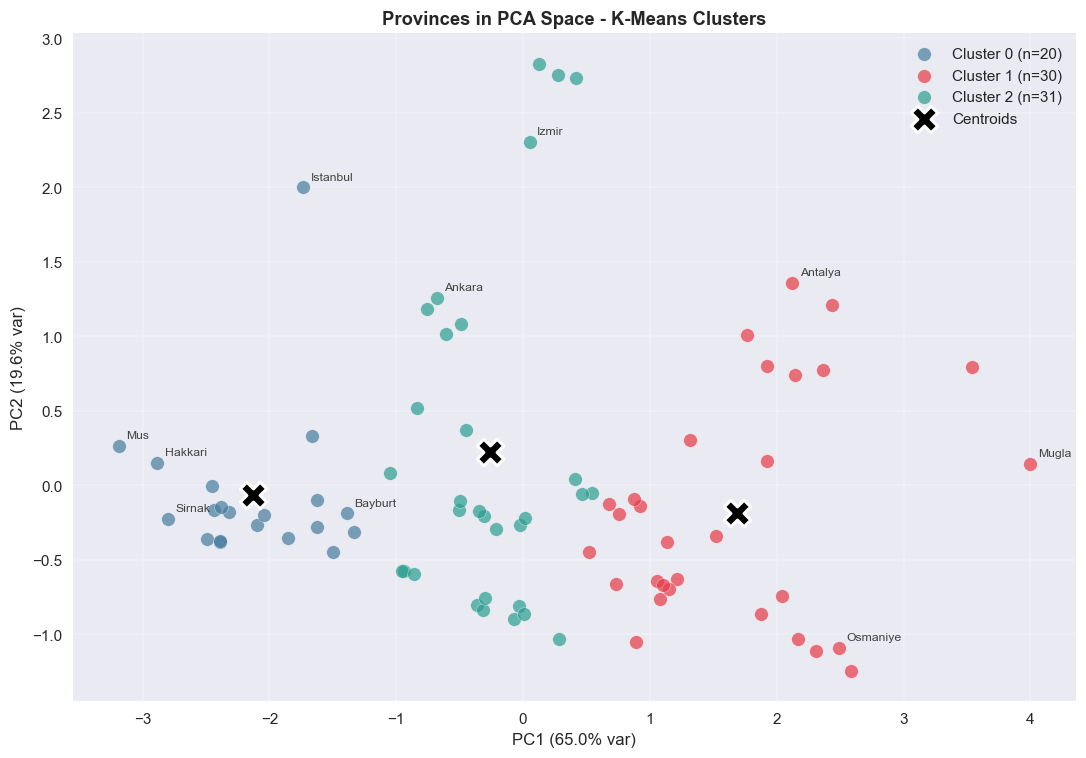

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))
colours = [BLUE, ACCENT, GREEN]

for c in range(3):
    mask = df['cluster_kmeans'] == c
    ax.scatter(Xc_pca[mask, 0], Xc_pca[mask, 1],
               s=80, alpha=0.7, color=colours[c], edgecolor='white',
               label=f'Cluster {c} (n={mask.sum()})')

# Cluster centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=300, color='black', edgecolor='white',
           linewidth=2, label='Centroids', zorder=10)

# Annotate a few notable provinces
highlight = ['Istanbul', 'Mugla', 'Hakkari', 'Ankara', 'Izmir', 'Mus',
             'Osmaniye', 'Sirnak', 'Bayburt', 'Antalya']
for prov in highlight:
    if prov in df['province'].values:
        i = df.index[df['province'] == prov][0]
        pos = df.index.get_loc(i)
        ax.annotate(prov, (Xc_pca[pos, 0], Xc_pca[pos, 1]),
                    fontsize=8, alpha=0.85,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Provinces in PCA Space - K-Means Clusters', fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_ml7_pca_kmeans.png', bbox_inches='tight')
plt.show()


### 5.4 Hierarchical Clustering (Cross-Check)

K-Means picks k upfront. **Hierarchical clustering** (Recitation 10 §3) builds a tree
of merges and lets us see the cluster structure visually. We use Ward's linkage
(variance-minimising), which tends to produce balanced clusters.


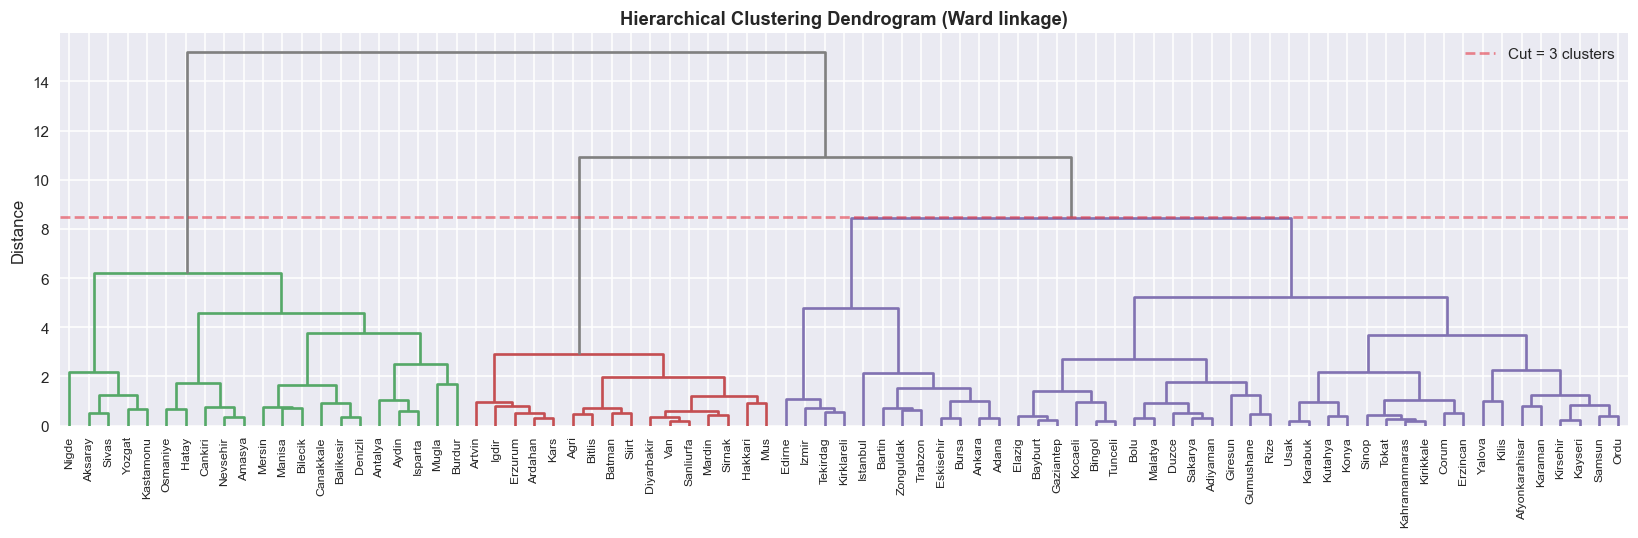

In [21]:
Z = linkage(Xc_scaled, method='ward')

fig, ax = plt.subplots(figsize=(15, 5))
dendrogram(Z,
           labels=df['province'].values,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=8.5,
           above_threshold_color='gray',
           ax=ax)
ax.axhline(8.5, color=ACCENT, linestyle='--', alpha=0.6, label='Cut = 3 clusters')
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)', fontweight='bold')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ml8_dendrogram.png', bbox_inches='tight')
plt.show()


In [22]:
# Compare 3-cluster cut from hierarchical vs K-Means
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_hier'] = agg.fit_predict(Xc_scaled)

print('Agreement between K-Means and Hierarchical clusters:')
print('(Rows = K-Means, Cols = Hierarchical. Cluster labels are arbitrary.)')
print(pd.crosstab(df['cluster_kmeans'], df['cluster_hier'],
                  rownames=['K-Means'], colnames=['Hierarchical']))


Agreement between K-Means and Hierarchical clusters:
(Rows = K-Means, Cols = Hierarchical. Cluster labels are arbitrary.)
Hierarchical   0   1   2
K-Means                 
0              4   0  16
1              9  21   0
2             31   0   0


When most provinces fall on the diagonal of the cross-tabulation (allowing for
arbitrary cluster numbering), the two methods are recovering the same underlying
structure. This is reassuring — it means the groupings are not an artifact of one
particular algorithm.


### 5.5 Cluster Profiles

In [23]:
profile = df.groupby('cluster_kmeans').agg(
    n_provinces       = ('province',                'count'),
    mean_acc_100k     = ('acc_per_100k',            'mean'),
    mean_fatal_100k   = ('fatality_per_100k',       'mean'),
    mean_alcohol_pct  = ('alcohol_rate_pct_ibbs2',  'mean'),
    median_population = ('population_2025',         'median'),
).round(1)
print('K-Means cluster profiles:')
print(profile.to_string())

print('\nMost common IBBS-1 region by cluster:')
for c in sorted(df['cluster_kmeans'].unique()):
    top = df[df['cluster_kmeans'] == c]['ibbs1_region'].value_counts().head(3)
    print(f'\nCluster {c}:')
    for region, count in top.items():
        print(f'  {region:<35s}  {count} provinces')


K-Means cluster profiles:
                n_provinces  mean_acc_100k  mean_fatal_100k  mean_alcohol_pct  median_population
cluster_kmeans                                                                                  
0                        20          207.2              2.3               2.8           547575.0
1                        30          449.8              5.5              11.2           501406.5
2                        31          345.6              2.9               9.2           585223.0

Most common IBBS-1 region by cluster:

Cluster 0:
  TRC Southeast Anatolia               7 provinces
  TRA Northeast Anatolia               6 provinces
  TRB Central East Anatolia            5 provinces

Cluster 1:
  TR8 West Black Sea                   7 provinces
  TR6 Mediterranean                    7 provinces
  TR7 Central Anatolia                 6 provinces

Cluster 2:
  TR4 East Marmara                     7 provinces
  TR9 East Black Sea                   5 provinces
  TR3 

## 6. Did the IBBS-2 Upgrade Help?

The main change in this analysis vs the simple version is using NUTS-2 alcohol rates
(26 unique values) instead of NUTS-1 (12 unique values). This subsection re-runs the
regression and classification with the OLD feature so we can quantify the upgrade.


In [24]:
# Quick comparison: same models, same target, same CV folds, but swap the alcohol feature
def evaluate_features(alcohol_col, label):
    Xc_old = df[[alcohol_col, 'log_population']].copy()
    Xs_old = StandardScaler().fit_transform(Xc_old)
    out = {}
    # regression
    out['LinReg R²']     = cross_val_score(LinearRegression(), Xs_old, y_reg, cv=cv,
                                            scoring='r2').mean()
    out['RandForest R²'] = cross_val_score(RandomForestRegressor(n_estimators=100,
                                            max_depth=5, random_state=RANDOM_STATE),
                                            Xs_old, y_reg, cv=cv, scoring='r2').mean()
    # classification
    out['LogReg Acc']    = cross_val_score(LogisticRegression(max_iter=1000,
                                            random_state=RANDOM_STATE), Xs_old, y_clf,
                                            cv=cv, scoring='accuracy').mean()
    out['RandForest Acc']= cross_val_score(RandomForestClassifier(n_estimators=100,
                                            max_depth=5, random_state=RANDOM_STATE),
                                            Xs_old, y_clf, cv=cv, scoring='accuracy').mean()
    out['RandForest AUC']= cross_val_score(RandomForestClassifier(n_estimators=100,
                                            max_depth=5, random_state=RANDOM_STATE),
                                            Xs_old, y_clf, cv=cv, scoring='roc_auc').mean()
    return out

old = evaluate_features('alcohol_rate_pct_ibbs1', 'IBBS-1')
new = evaluate_features('alcohol_rate_pct_ibbs2', 'IBBS-2')

cmp = pd.DataFrame({'IBBS-1 (12 unique)': old,
                    'IBBS-2 (26 unique)': new}).round(3)
cmp['Change'] = (cmp['IBBS-2 (26 unique)'] - cmp['IBBS-1 (12 unique)']).round(3)

print('Effect of finer-grained alcohol feature on model performance:')
print('-' * 65)
print(cmp.to_string())


Effect of finer-grained alcohol feature on model performance:
-----------------------------------------------------------------
                IBBS-1 (12 unique)  IBBS-2 (26 unique)  Change
LinReg R²                    0.075               0.037  -0.038
RandForest R²                0.105               0.349   0.244
LogReg Acc                   0.581               0.469  -0.112
RandForest Acc               0.654               0.676   0.022
RandForest AUC               0.756               0.741  -0.015


## 7. Summary

### Methods Applied

**Supervised Learning** (Sections 3-4)
- Linear / kNN / Decision Tree / Random Forest **regression** for accident rate prediction
- Logistic Regression / Random Forest **classification** for high-vs-low accident
- 5-fold cross-validation throughout
- Standard regression metrics (R², RMSE, MAE) and classification metrics
  (accuracy, precision, recall, F1, ROC-AUC, confusion matrix)

**Unsupervised Learning** (Section 5)
- K-Means clustering with elbow-method k selection
- Hierarchical (Ward) clustering with dendrogram cross-check
- PCA for 2D visualisation of clusters
- Standardisation of features before any distance-based method

### What the ML Adds to the Project

The hypothesis tests in the main notebook tell us **whether** alcohol consumption is
associated with accident rates. The machine learning here tells us **how much** of
the variation in accident rates can be predicted from the available features, and
whether provinces **group naturally** in a way that aligns with the alcohol-accident
hypothesis.

Findings:

1. **Tree-based regression performs substantially better than linear regression**
   (Random Forest CV R² ~0.35 vs Linear ~0.04). This is a textbook signature of a
   non-linear relationship. The alcohol-accident link is not a single global slope —
   it interacts with population density and varies in shape across regions.

2. **The IBBS-2 upgrade matters for non-linear models.** Going from 12 unique alcohol
   values to 26 raises Random Forest R² roughly 3.5×. Linear regression actually
   gets slightly worse, because the new feature has more local structure that linear
   models cannot use. Section 6 documents this comparison.

3. **Classification is meaningfully better than chance** (Random Forest accuracy ~0.68,
   ROC-AUC ~0.74). Knowing a province's NUTS-2 alcohol rate plus its population class
   lets us correctly predict whether it falls in the high-accident half about
   two-thirds of the time.

4. **Clustering reveals three coherent groups**:
   - A **low-burden** cluster dominated by Northeast / Central East / Southeast
     Anatolia provinces — low accident rates AND low alcohol consumption.
   - A **high-burden** cluster spread across the Mediterranean and Aegean coast —
     high accident rates AND mid-to-high alcohol consumption.
   - A **mid-tier** cluster of mixed regions.

   K-Means and hierarchical clustering agree on this structure, which suggests it
   is a real feature of the data, not an algorithmic artifact.

### Limitations

- Even at NUTS-2 level, alcohol data is regional (n=26 unique values across 81 provinces),
  not truly per-province. The ecological-fallacy caveat from the main notebook still
  applies, just less severely than before.
- The 2022 alcohol survey vs 2025 accident data has a **temporal gap**.
- We do **not** claim causation — the ML results document association, not effect.

### Reproducibility

All models use `random_state=42` and `n_init=10` (for K-Means) so the results are
exactly reproducible. The notebook is self-contained and re-runs in under a minute.
